In [ ]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:

import zipfile

with zipfile.ZipFile("/content/archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
import pandas as pd
import os
from PIL import Image

# 1. Setup paths
base_dir = "DATASET"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# 2. Read the CSV files
df_train = pd.read_csv("train_labels.csv")
df_test = pd.read_csv("test_labels.csv")

# 3. UPDATED function to add full file paths with class folders
def add_full_path(df, folder_path):
    # We use axis=1 to access columns (image and label) for each row
    # We convert the label to a string because folder names are strings
    df['path'] = df.apply(lambda row: os.path.join(folder_path, str(row['label']), row['image']), axis=1)
    return df

# 4. Apply the function
df_train = add_full_path(df_train, train_dir)
df_test = add_full_path(df_test, test_dir)

# Check the results
print(f"Training set: {len(df_train)} images")
# Shows the new path structure (e.g., DATASET/train/5/train_00001.jpg)
print(df_train[['image', 'label', 'path']].head())

# Example: Load the first image from the training set to verify
first_image_path = df_train.iloc[0]['path']

try:
    img = Image.open(first_image_path)
    print(f"\nSuccessfully loaded image: {first_image_path}")
    print(f"Image size: {img.size}")
except FileNotFoundError:
    print(f"\nError: Could not find image at {first_image_path}.")
    print("Please check that your folders 1-7 exist inside the train/test directories.")

Training set: 12271 images
                     image  label                                     path
0  train_00001_aligned.jpg      5  DATASET/train/5/train_00001_aligned.jpg
1  train_00002_aligned.jpg      5  DATASET/train/5/train_00002_aligned.jpg
2  train_00003_aligned.jpg      4  DATASET/train/4/train_00003_aligned.jpg
3  train_00004_aligned.jpg      4  DATASET/train/4/train_00004_aligned.jpg
4  train_00005_aligned.jpg      5  DATASET/train/5/train_00005_aligned.jpg

Successfully loaded image: DATASET/train/5/train_00001_aligned.jpg
Image size: (100, 100)


In [ ]:
# --- 1. Define Transformations (Based on PDF Best Practices) ---

# ImageNet statistics required for pre-trained models
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),       # PDF Step 1: Resolution 224x224
    transforms.RandAugment(num_ops=2, magnitude=9), # PDF Step 2: Strong Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD) # PDF Step 1: Normalization
])

# Test/Validation data should ONLY be resized and normalized (No Augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# --- 2. Define Custom Dataset Class ---

class RafDbDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # Read file name and label from CSV
        img_filename = self.annotations.iloc[index, 0] # Column 'image'
        label = self.annotations.iloc[index, 1]        # Column 'label' (1-7)

        # Adjust Label: PyTorch expects classes 0-6, but RAF-DB is usually 1-7
        label = label - 1

        # Construct path: DATASET/train/5/train_00001_aligned.jpg
        img_path = os.path.join(self.root_dir, str(label + 1), img_filename)

        # Open Image
        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            # Fallback or error logging
            print(f"Missing: {img_path}")
            # Return a dummy tensor or handle error appropriate to your pipeline
            return torch.zeros((3, 224, 224)), label

        # Apply Transforms
        if self.transform:
            image = self.transform(image)

        return image, label

# --- 3. Initialize Loaders ---

# Paths (Adjust to your actual path)
base_dir = "DATASET"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

train_dataset = RafDbDataset(
    csv_file='train_labels.csv',
    root_dir=train_dir,
    transform=train_transforms
)

test_dataset = RafDbDataset(
    csv_file='test_labels.csv',
    root_dir=test_dir,
    transform=test_transforms
)

# Batch Size: 32 or 64 is standard for 224x224 images depending on your GPU
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Verify Output
images, labels = next(iter(train_loader))
print(f"Batch Shape: {images.shape}")  # Should be [32, 3, 224, 224]
print(f"Labels: {labels}")             # Should be integers 0-6

Batch Shape: torch.Size([32, 3, 224, 224])
Labels: tensor([3, 4, 6, 3, 3, 3, 4, 3, 6, 3, 6, 3, 4, 3, 0, 4, 2, 0, 4, 3, 3, 6, 0, 2,
        6, 4, 3, 4, 3, 4, 0, 6])


Device being used: cuda
Initializing ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]



Epoch 1/25
----------
train Loss: 1.6860 Acc: 0.3822
val Loss: 1.5905 Acc: 0.3980
-> Best model saved!

Epoch 2/25
----------
train Loss: 1.5556 Acc: 0.4294
val Loss: 1.4355 Acc: 0.5049
-> Best model saved!

Epoch 3/25
----------
train Loss: 1.4204 Acc: 0.5376
val Loss: 1.3102 Acc: 0.6098
-> Best model saved!

Epoch 4/25
----------
train Loss: 1.2979 Acc: 0.6056
val Loss: 1.1930 Acc: 0.6558
-> Best model saved!

Epoch 5/25
----------
train Loss: 1.2069 Acc: 0.6471
val Loss: 1.1231 Acc: 0.6877
-> Best model saved!

Epoch 6/25
----------
train Loss: 1.1361 Acc: 0.6819
val Loss: 1.0693 Acc: 0.7040
-> Best model saved!

Epoch 7/25
----------
train Loss: 1.0837 Acc: 0.7072
val Loss: 1.0323 Acc: 0.7288
-> Best model saved!

Epoch 8/25
----------
train Loss: 1.0341 Acc: 0.7311
val Loss: 0.9953 Acc: 0.7448
-> Best model saved!

Epoch 9/25
----------
train Loss: 0.9928 Acc: 0.7524
val Loss: 0.9623 Acc: 0.7565
-> Best model saved!

Epoch 10/25
----------
train Loss: 0.9667 Acc: 0.7655
val Loss:

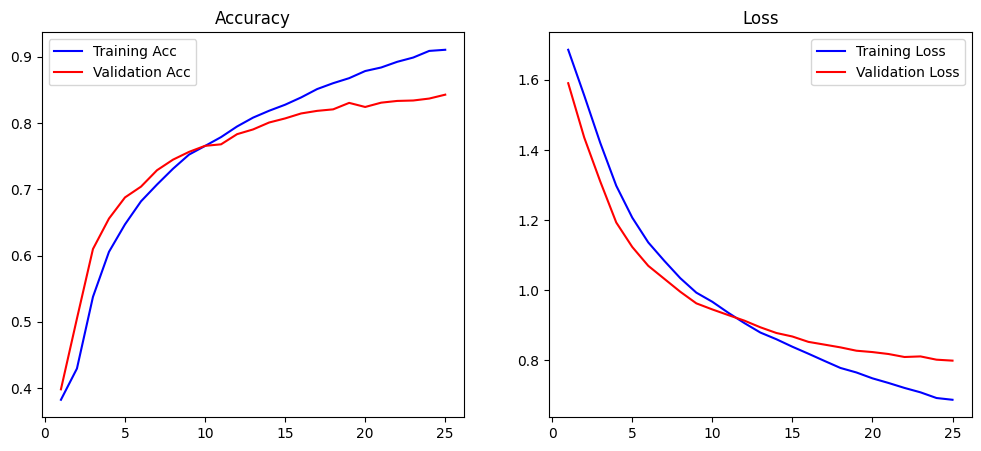

In [ ]:


# --- 1. Device Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device being used: {device}")

# --- 2. Define SAM Optimizer (Sharpness-Aware Minimization) ---
# This is required for SOTA results as per your PDF.
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f"Invalid rho, should be non-negative: {rho}"
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)  # Climb to the local maximum "sharpness"
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]  # Get back to "w" from "w + e(w)"
        self.base_optimizer.step()  # Do the actual update
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
            torch.stack([
                ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
                for group in self.param_groups for p in group["params"] if p.grad is not None
            ]), p=2
        )
        return norm

# --- 3. Model Setup (ResNet50) ---
print("Initializing ResNet50...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the final layer for 7 Emotion Classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)

model = model.to(device)

# --- 4. Loss and Optimizer Configuration ---
# Label Smoothing (0.1) as recommended
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# SAM Optimizer with SGD base
# Learning Rate: 0.001 (good starting point for fine-tuning)
optimizer = SAM(model.parameters(), base_optimizer=optim.SGD, lr=0.001, momentum=0.9, weight_decay=5e-4)

# --- 5. Training Function ---
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Lists for plotting
    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = test_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()

                        # SAM Optimizer Steps
                        optimizer.first_step(zero_grad=True)  # 1. Climb to worst spot

                        # Calculate loss again at the worst spot
                        criterion(model(inputs), labels).backward()

                        optimizer.second_step(zero_grad=True) # 2. Update weights

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best one
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), 'best_raf_db_model.pth')
                print("-> Best model saved!")

            # Save history
            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
                train_loss_history.append(epoch_loss)
            else:
                val_acc_history.append(epoch_acc.item())
                val_loss_history.append(epoch_loss)

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    return model, train_acc_history, val_acc_history, train_loss_history, val_loss_history

# --- 6. Helper to Plot Results ---
def plot_results(train_acc, val_acc, train_loss, val_loss):
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

# --- 7. START TRAINING ---
# Using 25 epochs as a standard starting point for fine-tuning
model, t_acc, v_acc, t_loss, v_loss = train_model(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=25
)

# Plot the training curves
plot_results(t_acc, v_acc, t_loss, v_loss)

Evaluating model on Test Set...

Classification Report:
              precision    recall  f1-score   support

    Surprise       0.85      0.82      0.83       329
        Fear       0.77      0.49      0.60        74
     Disgust       0.61      0.54      0.57       160
       Happy       0.93      0.94      0.94      1185
         Sad       0.76      0.85      0.80       478
       Angry       0.84      0.70      0.76       162
     Neutral       0.81      0.83      0.82       680

    accuracy                           0.84      3068
   macro avg       0.79      0.74      0.76      3068
weighted avg       0.84      0.84      0.84      3068



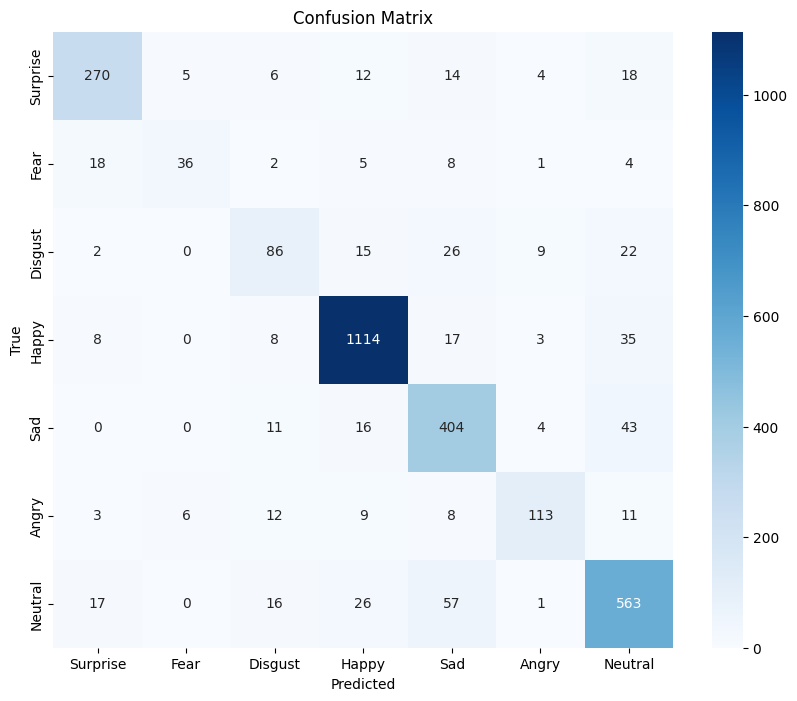

In [ ]:


def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    # Load the best weights saved during training
    model.load_state_dict(torch.load('best_raf_db_model.pth'))
    model.to(device)

    print("Evaluating model on Test Set...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # RAF-DB Labels (Usually 1-7 in this order)
    class_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']

    # 1. Classification Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Run Evaluation
evaluate_model(model, test_loader)

Please upload an image file...


Saving test_0280_aligned.jpg to test_0280_aligned.jpg


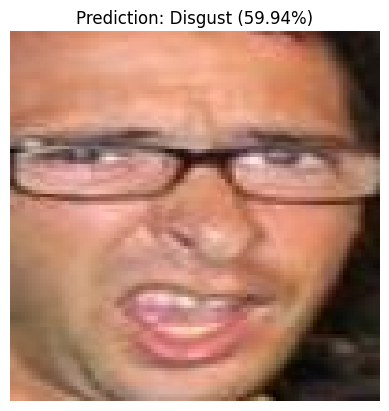

In [ ]:
from PIL import Image
from google.colab import files

def predict_custom_image(model_path='best_raf_db_model.pth'):
    # 1. Upload Image
    print("Please upload an image file...")
    uploaded = files.upload()
    file_name = next(iter(uploaded))

    # 2. Load and Preprocess
    img = Image.open(file_name).convert('RGB')

    # Apply the same transforms as the Test Set
    # (Resize to 224x224 and Normalize)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # 3. Predict
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 7)
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_prob, top_class = torch.max(probabilities, 1)

    # Map to Class Names
    class_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    prediction = class_names[top_class.item()]
    confidence = top_prob.item() * 100

    # 4. Show Result
    plt.imshow(img)
    plt.title(f"Prediction: {prediction} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Run Prediction
predict_custom_image()